# Notebook 01 — Data Extraction & BigQuery Documentation

*Project:* GA4 + GTM Analytics — Google Merchandise Store  
*Analyst:* Philip Ocheri  
*Data Source:* `bigquery-public-data.google_analytics_sample.ga_sessions_*`  
*Period:* January 1, 2017 — December 31, 2017  

---

## 1. Project Overview

This project analyses real Google Analytics 360 data exported from the Google Merchandise Store via BigQuery. The pipeline covers:
- GA4/UA session and transaction data extraction via BigQuery SQL
- GTM tag audit and tracking integrity review
- KPI dashboard design for a DTC e-commerce brand
- Channel attribution and conversion analysis
- CDP integration approach using Segment-style architecture
- CRM lifecycle mapping via HubSpot

## 2. Data Source & Schema

The dataset is Google Analytics 360 (obfuscated) session data from the Google Merchandise Store, publicly available via BigQuery at:

`bigquery-public-data.google_analytics_sample.ga_sessions_*`

Each row represents one user session. Key fields used in this project:

| Field | Description |
|---|---|
| date | Session date (YYYYMMDD) |
| totals.sessions | Number of sessions |
| totals.transactions | Completed transactions |
| totals.totalTransactionRevenue | Revenue in micros (divide by 1,000,000) |
| totals.bounces | Sessions with single pageview |
| totals.visits | Total visits |
| trafficSource.medium | Traffic medium (organic, cpc, referral) |
| trafficSource.source | Traffic source (google, direct, etc.) |
| device.deviceCategory | Device type (desktop, mobile, tablet) |
| geoNetwork.country | User country |

The following SQL was executed in BigQuery Sandbox under the veteran-analytics project to extract full year 2017 session data. Results were exported locally as a CSV file.

In [1]:
# SQL executed in BigQuery — documented here for reproducibility

sql_query = """
SELECT
  date,
  COUNT(*) AS total_sessions,
  SUM(totals.transactions) AS total_transactions,
  SUM(totals.totalTransactionRevenue) / 1000000 AS total_revenue,
  SUM(totals.visits) AS total_visits,
  SUM(totals.bounces) AS total_bounces
FROM
  `bigquery-public-data.google_analytics_sample.ga_sessions_*`
WHERE
  _TABLE_SUFFIX BETWEEN '20170101' AND '20171231'
GROUP BY date
ORDER BY date ASC
"""

print("Query documented. CSV exported locally from BigQuery as ga_sessions_2017_daily.csv")

Query documented. CSV exported locally from BigQuery as ga_sessions_2017_daily.csv


In [2]:
## 4. Load Extracted Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the BigQuery export
df = pd.read_csv('../data/raw/ga_sessions_2017_daily.csv')

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
df.head(10)

Shape: (213, 6)
Columns: ['date', 'total_sessions', 'total_transactions', 'total_revenue', 'total_visits', 'total_bounces']
Date range: 20170101 to 20170801


,date,total_sessions,total_transactions,total_revenue,total_visits,total_bounces
0,20170101,1364,11,993.01,1364,702
1,20170102,1620,18,1027.60,1620,774
2,20170103,2403,32,4574.74,2403,1087
3,20170104,2390,31,4777.14,2390,1045
4,20170105,2193,41,9097.97,2193,1008
5,20170106,2210,26,4335.24,2210,1044
6,20170107,1615,8,388.27,1615,855
7,20170108,1637,11,1615.30,1637,846
8,20170109,2308,39,7170.50,2308,1046
9,20170110,2268,23,5982.74,2268,1060


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the BigQuery export
df = pd.read_csv('../data/raw/ga_sessions_2017_daily.csv')

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
df.head(10)

Shape: (213, 6)
Columns: ['date', 'total_sessions', 'total_transactions', 'total_revenue', 'total_visits', 'total_bounces']
Date range: 20170101 to 20170801


,date,total_sessions,total_transactions,total_revenue,total_visits,total_bounces
0,20170101,1364,11,993.01,1364,702
1,20170102,1620,18,1027.60,1620,774
2,20170103,2403,32,4574.74,2403,1087
3,20170104,2390,31,4777.14,2390,1045
4,20170105,2193,41,9097.97,2193,1008
5,20170106,2210,26,4335.24,2210,1044
6,20170107,1615,8,388.27,1615,855
7,20170108,1637,11,1615.30,1637,846
8,20170109,2308,39,7170.50,2308,1046
9,20170110,2268,23,5982.74,2268,1060


## 5. Basic Data Validation

In [4]:
# Check data types and nulls
print("=== DATA TYPES ===")
print(df.dtypes)
print("\n=== NULL VALUES ===")
print(df.isnull().sum())
print("\n=== SUMMARY STATISTICS ===")
print(df.describe())

=== DATA TYPES ===
date                    int64
total_sessions          int64
total_transactions      int64
total_revenue         float64
total_visits            int64
total_bounces           int64
dtype: object

=== NULL VALUES ===
date                  0
total_sessions        0
total_transactions    0
total_revenue         0
total_visits          0
total_bounces         0
dtype: int64

=== SUMMARY STATISTICS ===
               date  total_sessions  total_transactions  total_revenue  \
count  2.130000e+02      213.000000          213.000000     213.000000   
mean   2.017042e+07     2193.708920           31.201878    4830.643803   
std    2.024957e+02      443.414145           14.722964    5490.325039   
min    2.017010e+07     1251.000000            3.000000      93.540000   
25%    2.017022e+07     1829.000000           19.000000    1917.980000   
50%    2.017042e+07     2245.000000           31.000000    4101.080000   
75%    2.017061e+07     2477.000000           40.000000    5899

## 6. Revenue & Session Overview

In [5]:
# Convert date to datetime
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d')
df['month'] = df['date'].dt.month
df['month_name'] = df['date'].dt.strftime('%b')
df['week'] = df['date'].dt.isocalendar().week

# Fill nulls in revenue and transactions
df['total_revenue'] = df['total_revenue'].fillna(0)
df['total_transactions'] = df['total_transactions'].fillna(0)
df['total_bounces'] = df['total_bounces'].fillna(0)

# Key annual totals
total_sessions     = df['total_sessions'].sum()
total_revenue      = df['total_revenue'].sum()
total_transactions = df['total_transactions'].sum()
total_bounces      = df['total_bounces'].sum()
bounce_rate        = (total_bounces / total_sessions) * 100
conversion_rate    = (total_transactions / total_sessions) * 100
avg_order_value    = total_revenue / total_transactions

print("=== 2017 ANNUAL SUMMARY ===")
print(f"Total Sessions:      {total_sessions:,.0f}")
print(f"Total Revenue:       ${total_revenue:,.2f}")
print(f"Total Transactions:  {total_transactions:,.0f}")
print(f"Bounce Rate:         {bounce_rate:.2f}%")
print(f"Conversion Rate:     {conversion_rate:.2f}%")
print(f"Avg Order Value:     ${avg_order_value:,.2f}")

=== 2017 ANNUAL SUMMARY ===
Total Sessions:      467,260
Total Revenue:       $1,028,927.13
Total Transactions:  6,646
Bounce Rate:         50.00%
Conversion Rate:     1.42%
Avg Order Value:     $154.82


## 7. Daily Sessions & Revenue Chart

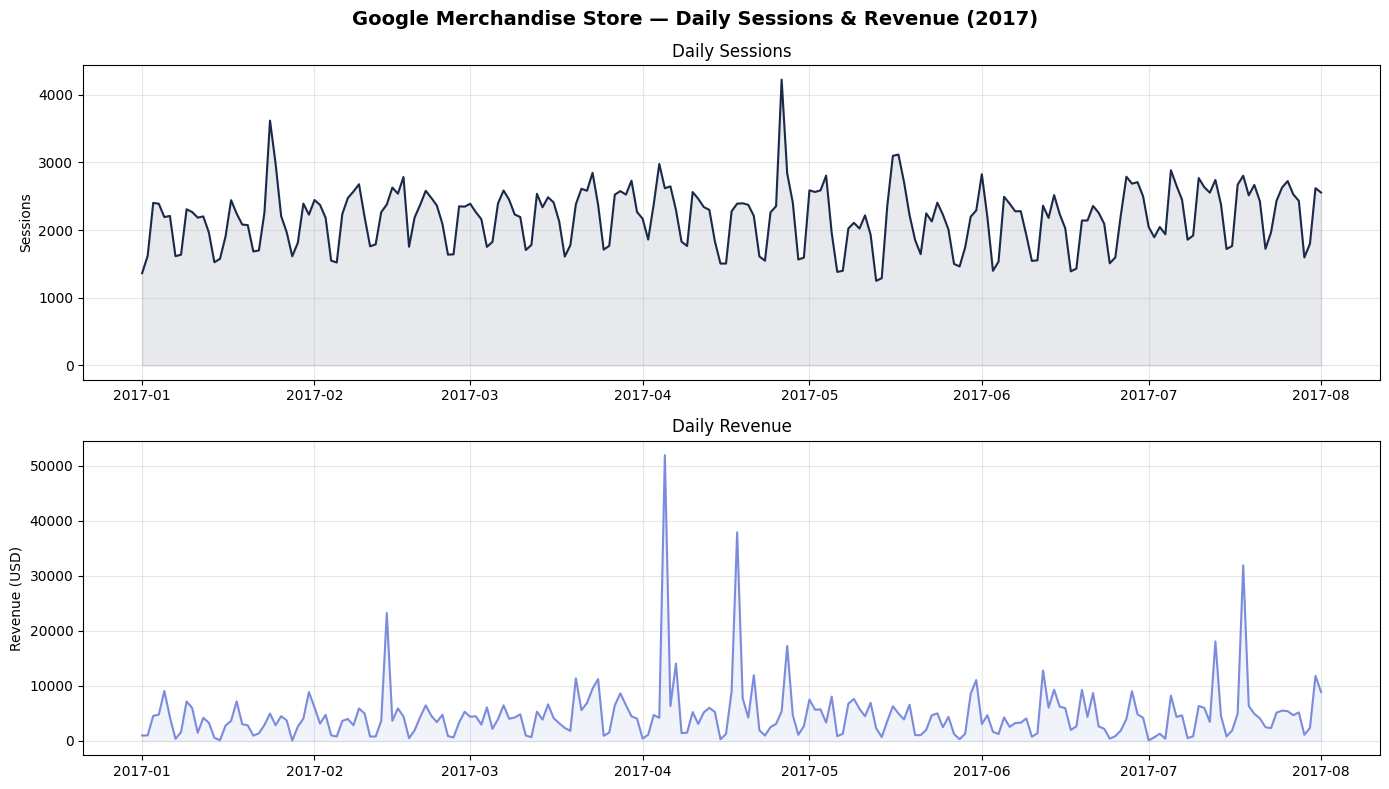

Chart saved to reports/


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Google Merchandise Store — Daily Sessions & Revenue (2017)',
             fontsize=14, fontweight='bold')

# Sessions
axes[0].plot(df['date'], df['total_sessions'], color='#1B2A4A', linewidth=1.5)
axes[0].fill_between(df['date'], df['total_sessions'], alpha=0.1, color='#1B2A4A')
axes[0].set_ylabel('Sessions')
axes[0].set_title('Daily Sessions')
axes[0].grid(True, alpha=0.3)

# Revenue
axes[1].plot(df['date'], df['total_revenue'], color='#7B8CDE', linewidth=1.5)
axes[1].fill_between(df['date'], df['total_revenue'], alpha=0.1, color='#7B8CDE')
axes[1].set_ylabel('Revenue (USD)')
axes[1].set_title('Daily Revenue')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/01_daily_sessions_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to reports/")

## 8. Save Processed Data

In [7]:
# Save cleaned version for next notebook
df.to_csv('../data/processed/ga_sessions_2017_cleaned.csv', index=False)
print("Saved: data/processed/ga_sessions_2017_cleaned.csv")
print(f"Rows: {len(df)} | Columns: {len(df.columns)}")

Saved: data/processed/ga_sessions_2017_cleaned.csv
Rows: 213 | Columns: 9
